# Project Setup

## Project Details (Add Project Name)


**Dataset:** Kaggle Home Credit Defaults Risk (application_train.csv)

**Author:** Chuch  

**Date:** 11-07-2026

**Objective:** Complete EDA Analysis (Part 2 of 7 for full project)  

**Status:** In Progress

## Environment and Imports

In [ ]:
# ══════════════════════════════════════════════════════
# Environment Setup
# ══════════════════════════════════════════════════════

# ── Standard Library ──────────────────────────────────
import os
import sys
import warnings

# ── Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Machine Learning ──────────────────────────────────
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display

def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent

repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

import python_style_util as psu
import evaluation_utils as eu
import missingness_viz as mv        # missingess assessment functions

# ══════════════════════════════════════════════════════
# Display Settings
# ══════════════════════════════════════════════════════

%matplotlib inline

# Pandas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')



# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Style Guide

In [ ]:
psu.show_tokens()
psu.show_fonts()


## Display Setttings

In [ ]:
# --- Pandas ---

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---

np.set_printoptions(
    precision=4,        # decimal places (you have this)
    suppress=True,      # no scientific notation (you have this)
    linewidth=120,      # wrap width (you have this)
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---

%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---

InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---

psu.set_style()

## Data Loading

In [ ]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('this_notebook.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')

# Load data
df = pd.read_csv('../../../Home Credit Default Risk/application_train.csv', sep=',')
desc = pd.read_csv('../../../Home Credit Default Risk/HomeCredit_columns_description.csv', sep=',', encoding='cp1252')


# Project Body

### 1.1 Structural Skeleton

Before any feature-level analysis begins, two columns need to be separated from the working feature set: SK_ID_CURR, the unique row identifier, and TARGET, the label being predicted. Neither is a feature — SK_ID_CURR carries no predictive information about default risk, and TARGET is the outcome being modelled, not an input to it. Both are extracted into their own variables (df_id, df_target) so every dtype summary, missingness check, distribution plot, and correlation matrix from this point forward operates purely on the candidate feature set in df. df_target is reintroduced explicitly wherever it's needed — class balance checks, bivariate default-rate analysis, and ultimately as y when the model is fit — and df_id is kept aside to re-attach predictions to the original applicant ID at scoring time.

#### Isolation and Shape

Isolate SK_ID_CURR and Target. Separate them from the training data.

In [ ]:
df_id = df['SK_ID_CURR']

df_target = df['TARGET']

df = df.drop(columns = ['SK_ID_CURR', 'TARGET'])

In [ ]:
# Look at the shape of the dataset - understand breadth and depth

df.shape

**Observation:** Once SK_ID_CURR and TARGET are removed, the feature set should sit at 307,511 rows and 120 columns.

**Decision:** With roughly 2,500 rows for every column (307,511 rows against 120), the row-to-feature ratio is comfortably large enough that overfitting from dimensionality alone is not a meaningful risk at this stage. No columns will be dropped on parameter-count grounds, and the full feature set proceeds into EDA. This doesn't rule out removing or engineering features later — for reasons like multicollinearity, near-zero variance, or leakage — but those will be addressed if and when they're identified, not pre-emptively here.

In [ ]:
# Overview of the data through a scrollable table

# Using this to get an understanding of what the entries in each column look like 

df.head(10)

**Observation:** A quick scan of the first ten rows confirms a mix of numeric, categorical, and flag-style columns, with a loose grouping visible by column-name prefix (FLAG_*, NAME_*, AMT_*, DAYS_*) — an early hint that columns cluster by domain and naming convention, which the rest of this EDA leans on directly through the domain-bucket structure.

#### Description Lookup For Reference 

With 122 columns and no realistic way to memorise a full data dictionary, this section builds a lookup so any column's meaning is one line away rather than a trip back to the source CSV. HomeCredit_columns_description.csv documents all seven tables in the Home Credit dataset, so a column name like AMT_CREDIT appears once per table it belongs to — filtering to Table == 'application_{train|test}.csv' before indexing on Row is what keeps the lookup pointing at the right description rather than returning an ambiguous match. 

Once built, description_index['COLUMN_NAME'] returns the plain-English description for any column in df.

In [ ]:
# Filter to the application table first (Row repeats across the 7 source tables,
# so filtering before indexing avoids ambiguous/duplicate matches)
desc_app = desc[desc['Table'] == 'application_{train|test}.csv'].set_index('Row')

description_index = {}

for column in df.columns:
    if column in desc_app.index:
        description_index[column] = desc_app.loc[column, 'Description']
        
        
description_index['NAME_CONTRACT_TYPE']

#### Datatypes Overview

Pandas' inferred dtype is a starting point, not a final classification — it describes how values are stored, not what they mean. A column flagged int64 could be a true count (CNT_CHILDREN), a binary flag, or an ordinal rating (REGION_RATING_CLIENT), and each needs different downstream treatment. This pass is purely the storage-level inventory; statistical-type reclassification (continuous / discrete / ordinal / nominal / binary) happens once the domain-bucket structure is in place to give it context.

In [ ]:
# Look at the types of data throughout the dataset as well as the distribution of these types

# dtypes overview per column
df.dtypes

df.dtypes.value_counts(normalize=True)

**Observation:** 54% of columns are stored as float64, 33% as int64, and 13% as str — a clear numeric majority by raw dtype. That split is misleading on its own: several int64/float64 columns are binary flags (FLAG_*) or ordinal ratings (REGION_RATING_CLIENT) rather than true continuous or discrete measures, and won't behave like typical numeric features in distribution checks, scaling, or correlation analysis.

**Decision:** Storage dtype alone isn't sufficient for choosing imputation or encoding strategy — the next stage reclassifies every column by statistical type rather than relying on the float64/int64/str split shown here. That reclassification sits inside the domain-bucket structure (Security/Collateral, Personal, Financial/Credit, Social/Network, Application/Process) being built out next, so each column's treatment is informed by both what it represents and how it's stored.

### 1.2 Target Distribution and Class Imbalance

Examining df['TARGET] directly to understand the proportion of applicants currently defaulting

In [ ]:
df_target.value_counts()

df_target.value_counts(normalize=True)

**Observation:** 8% of applicants from the training dataset are defaulting. Even though 92% of applicants do not default, this is an extremely high number for mortgage default rates - almost catastrpohic to a loan book's long term health. 

**Decision:**  Accuracy is not a reliable measure of model performance given the dataset's 92% non-default rate. A model that predicts "no default" for every applicant would still score 92% accuracy while providing no practical value, since it fails to identify a single true defaulter.

Independent of this, the train/validation split must be stratified on TARGET, ensuring both subsets preserve the same ~92/8 default ratio as the full dataset. This is a data-integrity safeguard, not a fix for the accuracy problem above.

Given the asymmetric cost of missing a genuine defaulter, recall will be treated as the primary early-stage performance metric, since it directly measures how many actual defaulters the model identifies. Recall will not be optimized in isolation, however: it will be tracked alongside precision to prevent the model from compensating by over-rejecting creditworthy applicants, which would erode loan volume and undermine overall profitability.

### 1.3 Statistical-type Reference Lookup

In [ ]:
statistical_type_index = {}

nunique_counts = df.nunique()

for column in df.columns:
    
    n_unique = nunique_counts[column]
    
    dtype = df[column].dtype
    
    if n_unique == 2:
        statistical_type_index[column] = 'binary'
        
    elif n_unique > 50 and dtype in ['float64', 'int64']:
        statistical_type_index[column] = 'continuous'
    
    else:
        statistical_type_index[column] = 'needs review'
    
review_cols = [col for col, label in statistical_type_index.items() if label == 'needs review']

for col in review_cols:
    print(col, df[col].unique()[:10], description_index.get(col))
    

In [ ]:
print(len(review_cols))

df[review_cols].dtypes

df[review_cols].columns

In [ ]:
df[review_cols].sample(10)

In [ ]:
df['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

description_index['AMT_REQ_CREDIT_BUREAU_YEAR']



**ACTION:** Going through each column that was not able to be assigned a statistical category by initial methods and assigning them based on column value and description

In [ ]:
# CODE_GENDER

statistical_type_index.update(dict.fromkeys(['CODE_GENDER'], 'nominal'))  # Imputation needed on 'XNA' value - may drop rows as there are only 4 entries here

# CNT_CHILDREN

statistical_type_index.update(dict.fromkeys(["CNT_CHILDREN"], 'discrete'))

# NAME_TYPE_SUITE

statistical_type_index.update(dict.fromkeys(['NAME_TYPE_SUITE'], 'nominal'))

# NAME_INCOME_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_INCOME_TYPE'], 'nominal'))

# NAME_EDUCATION_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_EDUCATION_TYPE'], 'ordinal'))

# NAME_FAMILY_STATUS

statistical_type_index.update(dict.fromkeys(['NAME_FAMILY_STATUS'], 'nominal'))

# NAME_HOUSING_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_HOUSING_TYPE'], 'nominal'))

# OCCUPATION TYPE

statistical_type_index.update(dict.fromkeys(['OCCUPATION_TYPE'], 'nominal'))

# CNT_FAM_MEMBERS

statistical_type_index.update(dict.fromkeys(['CNT_FAM_MEMBERS'], 'discrete'))

# REGION_RATING_CLIENT

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT'], 'ordinal'))

# REGION_RATING_CLIENT_W_CITY

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT_W_CITY'], 'ordinal'))

# WEEKDAY_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['WEEKDAY_APPR_PROCESS_START'], 'nominal'))

# HOUR_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['HOUR_APPR_PROCESS_START'], 'nominal'))

# ORGNAIZATION_TYPE

statistical_type_index.update(dict.fromkeys(['ORGANIZATION_TYPE'], 'nominal'))

# ELEVATORS_MODE

statistical_type_index.update(dict.fromkeys(['ELEVATORS_MODE'], 'continuous'))

# ENTRANCES_MODE	
 
statistical_type_index.update(dict.fromkeys(['ENTRANCES_MODE'], 'continuous'))
 
# FLOORSMAX_MODE	

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MODE'], 'continuous'))
 
# FLOORSMIN_MODE	
 
statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MODE'], 'continuous'))
 
# ELEVATORS_MEDI	
 
statistical_type_index.update(dict.fromkeys(['ELEVATORS_MEDI'], 'continuous')) 
 
# ENTRANCES_MEDI	
 
statistical_type_index.update(dict.fromkeys(['ENTRANCES_MEDI'], 'continuous'))
 
# FLOORSMAX_MEDI	

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MEDI'], 'continuous'))

# FLOORSMIN_MEDI

statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MEDI'], 'continuous'))

#FONDKAPREMONT_MODE

statistical_type_index.update(dict.fromkeys(['FONDKAPREMONT_MODE'], 'nominal'))
	
#HOUSETYPE_MODE	

statistical_type_index.update(dict.fromkeys(['HOUSETYPE_MODE'], 'nominal'))

# WALLSMATERIAL_MODE	

statistical_type_index.update(dict.fromkeys(['WALLSMATERIAL_MODE'], 'nominal'))

# OBS_30_CNT_SOCIAL_CIRCLE	

statistical_type_index.update(dict.fromkeys(['OBS_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_30_CNT_SOCIAL_CIRCLE	

statistical_type_index.update(dict.fromkeys(['DEF_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# OBS_60_CNT_SOCIAL_CIRCLE	

statistical_type_index.update(dict.fromkeys(['OBS_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_60_CNT_SOCIAL_CIRCLE	

statistical_type_index.update(dict.fromkeys(['DEF_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_HOUR	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_HOUR'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_DAY	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_DAY'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_WEEK	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_WEEK'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_MON	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_MON'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_QRT	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_QRT'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_YEAR

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_YEAR'], 'discrete'))


In [ ]:
len([col for col, label in statistical_type_index.items() if label == 'needs review']) 

len(statistical_type_index)

## 1.4 Data Quality Fixes

Before missingness, univariate, or bivariate analysis can be trusted, every column needs a pass for data that's technically present but not genuinely valid — placeholder or sentinel values standing in for a real measurement (e.g. DAYS_EMPLOYED's 365243), invalid category codes standing in for missing or unknown (e.g. CODE_GENDER's XNA), or other implausible values that pandas won't flag as null but that would silently corrupt every downstream statistic — mean, skew, correlation, missingness percentage — computed on top of them. Each issue found here gets an explicit decision: convert to NaN (optionally with a companion flag column to preserve the reason for the gap as a feature in its own right), recode, or drop the affected rows outright. The goal isn't to defer these values to the missingness section — it's to ensure that by the time missingness is assessed, every NaN in the dataset represents genuine absence rather than disguised garbage.

In [ ]:
# Creating column lists for each statistical category

def cols_by_type(stat_type):
    return [col for col, label in statistical_type_index.items() if label == stat_type]

continuous_cols = cols_by_type('continuous')
ordinal_cols = cols_by_type('ordinal')
nominal_cols = cols_by_type('nominal')
discrete_cols = cols_by_type('discrete')
binary_cols = cols_by_type('binary')


### Continuous Data Quality Check

In [ ]:
# Data Quality - continuous type check

df[continuous_cols].describe()

df[continuous_cols].nunique()

df[continuous_cols].skew()

# DAYS_EMPLOYED max == 365243 (incorrect)

df['DAYS_EMPLOYED'].value_counts()

In [ ]:
# Creating a flag column to keep record of missing values - later feature engineering

df['DAYS_EMPLOYED_ANOM'] = df['DAYS_EMPLOYED'] == 365243

# Swapping out '365243' for NaN

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Verify result

print(df['DAYS_EMPLOYED'].isna().sum())

df['DAYS_EMPLOYED_ANOM'].value_counts()


**Observation:** column 'DAYS_EMPLOYED" was observed to have a sentinel shown as '365243' representing missing data.

**Decision:** flagging column was added to the dataset to represent these missing values for future feature creation then the missing values were converted to 'NaN' via np.nan


### Discrete Data Quality Check

In [ ]:
# Data Quality - discrete type check


df[discrete_cols].describe()

df[discrete_cols].skew()

df[discrete_cols].nunique()


In [ ]:
description_index['AMT_REQ_CREDIT_BUREAU_QRT']

df['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

df['AMT_REQ_CREDIT_BUREAU_QRT'].dtype

df = df.drop(df[df['AMT_REQ_CREDIT_BUREAU_QRT'] == 261].index)

**Observation:** One borrower is shown to have 261 credit enquiries in the last three months. Logically this is 3 enquiries every single day for hte last 3 months and would be near impossible to do this. 

**Decision:** This entry is clearly an outlier in this column and as such the row will be dropped from the dataset.

### Nominal Data Quality Check

In [ ]:
# Data Quality - nominal type check

nominal_cols

df[nominal_cols].astype(str).describe()

df[nominal_cols].nunique()


In [ ]:
# CODE_GENDER Fixing - 'XNA" Entry


df['CODE_GENDER_ANOM'] = df['CODE_GENDER'] == 'XNA'

df['CODE_GENDER_ANOM'].value_counts()

df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', pd.NA)

df['CODE_GENDER'].value_counts()


In [ ]:
# ORGANIZATION_TYPE Fixing - 'XNA" Entry


df['ORGANIZATION_TYPE_ANOM'] = df['ORGANIZATION_TYPE'] == 'XNA'

df['ORGANIZATION_TYPE_ANOM'].value_counts()

df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', pd.NA)

df['ORGANIZATION_TYPE'].value_counts()


**Observation:** columns 'CODE_GENDER' and 'ORGANIZATION_TYPE' were observed to have sentinel values representing missing data shown as 'XNA'. ORGANIZATION_TYPE_ANOM and DAYS_EMPLOYED_ANOM both have 55,374 True.

**Decision:** flagging columns were added to the dataset to represent these missing values for future feature creation then converted to 'NaN' via pd.NA. 

ORGANIZATION_TYPE_ANOM and DAYS_EMPLOYED_ANOM will be reviewed further to determine if these are the same borrowers and whether this missingness is due to unemployment.

ORGANIZATION_TYPE_ANOM,False,True
DAYS_EMPLOYED_ANOM,,
False,252136,0
True,0,55374


<Axes: xlabel='ORGANIZATION_TYPE_ANOM', ylabel='DAYS_EMPLOYED_ANOM'>

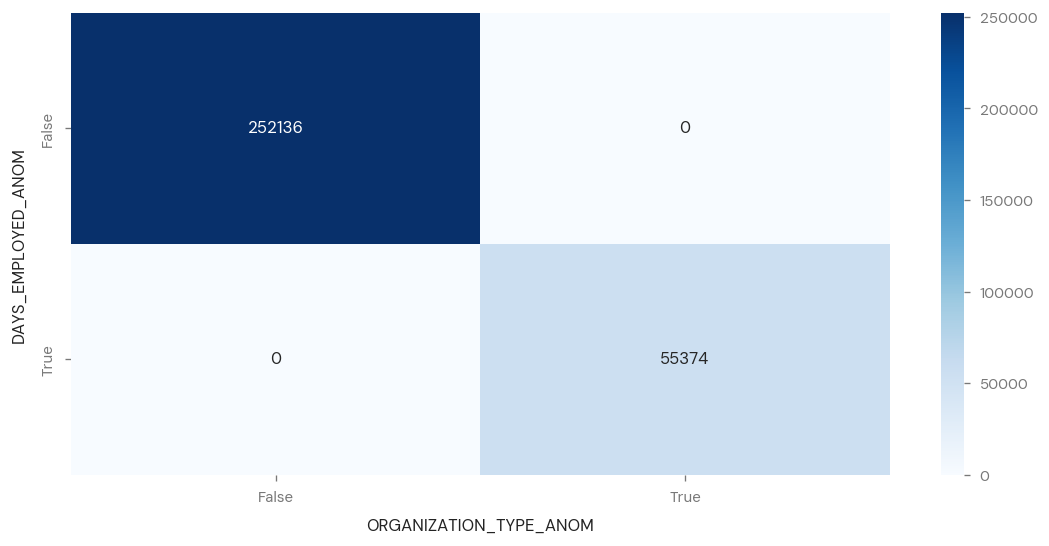

In [34]:
pd.crosstab(df['DAYS_EMPLOYED_ANOM'], df['ORGANIZATION_TYPE_ANOM'])

sns.heatmap(pd.crosstab(df['AM'], df['ORGANIZATION_TYPE_ANOM']), annot=True, fmt='d', cmap='Blues')

**Observation:** These every missing row had both of these values missing. This indicates MNAR missingness.

**Decision:** Missing flag columns created for each can be used as a signal in future but will likely not be used to engineer new features.

### Ordinal Data Quality Check

In [ ]:
# Data Quality - ordinal type check

df[ordinal_cols].describe()

df[ordinal_cols].astype(str).describe()

df[ordinal_cols].nunique()


**Observation:** Ordinal columns do not show any signs of have any data quality issues that need to be addressed here.

**Decision:** Do not perform any actions on this subset of the data.

### Binary Data Quality Check

In [ ]:
# Data Quality - binary type check

df[binary_cols].describe()

df[binary_cols].nunique()

# Binary columns fine

**Observation:** Binary columns do not show any signs of have any data quality issues that need to be addressed here. All columns have two unqiue values and min = 0 and max = 1.

**Decision:** Do not perform any actions on this subset of the data.

## 1.5 Missingness Assessment

### Missing Percentage Per Column

In [ ]:
missingness_per_column = []

for column in df:

    column_check = df["DAYS_EMPLOYED"].isnull().value_counts(normalize=True).T
    
    missingness_per_column = pd.concat([missingness_per_column, column_check])

missingness_per_column.sample(10)


TypeError: first argument must be an iterable of pandas objects, you passed an object of type "Series"